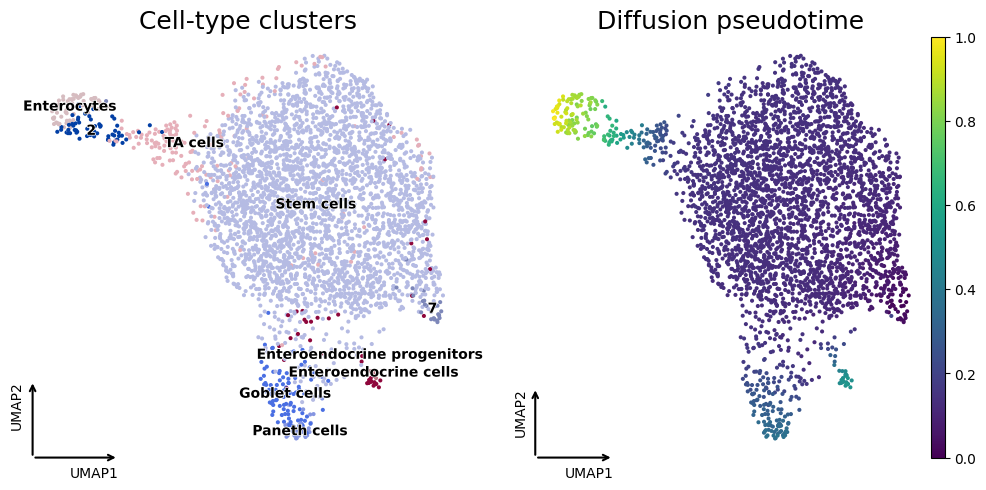

  Spatial clustering: 1 clusters via KMeans on X_pca (50D)
  Built 6 window pairs across 1 clusters (skipped 0 small clusters)
  Window size: 500, step: 500


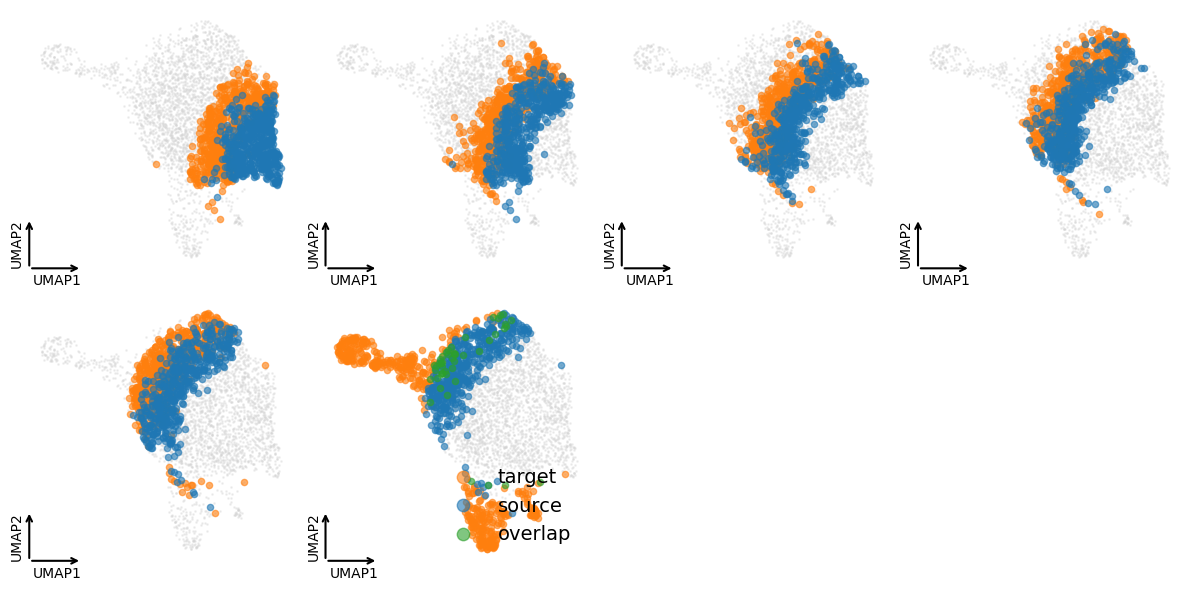

In [31]:
# imports
import os

import velot
import scanpy as sc

import matplotlib.pyplot as plt

# Murine dataset
adata = sc.read_h5ad("../../article/data/Murine/preprocessed.h5ad")

velot.pp.pseudotime(adata, root_cluster="Stem cells", cluster_key="cell_type")
adata.obs["clusters_id"] = adata.obs["cell_type"].cat.codes

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
velot.pl.dataset_overview_simple(adata, color="cell_type",
    title="Cell-type clusters", inframe=True,
    show=False, ax=axes[0]
)
velot.pl.dataset_overview_simple(adata, color="pseudotime",
    title="Diffusion pseudotime",
    show=False, ax=axes[1]
)
plt.tight_layout()
plt.show()

## Velocity field computation
SHARED_WINDOW = dict(
    min_window_size=100,
    overlap_fraction=0.0,
    tail_handling="drop",
    tail_threshold=20
)
SHARED = dict(
    smooth=True,
    n_epochs=100,
    lambda_smooth=0.1,
    lambda_curl=0.1,
    lambda_divergence=0.0,
    k_smooth=30,
    project_umap=True,
    verbose=True,
    **SHARED_WINDOW
)
METHODS = {
    "velot": dict(use_graph=False, ot_solver="emd")
}

velot.tl.build_windows(adata, "X_pca", 1, 500, 0, 100, None, "drop", random_state=0)
velot.pl.windows(adata)

VelOT: Computing velocity field
  Estimator: ot / emd, euclidean cost/max, barycentric, no kNN graph
  Basis: X_pca (50D)
  Cells: 3452
  Smoothing: ON

[1/4] Building spatial-temporal windows...
  Spatial clustering: 1 clusters via KMeans on X_pca (50D)
  Built 6 window pairs across 1 clusters (skipped 0 small clusters)
  Window size: 500, step: 500

[2/4] Computing OT velocity...
  OT velocity computed: 3000 cells with velocity, 452 without (452 never a source) (will be filled by smoothing)
  Plan sharpness: mean targets per cell (n_eff) = 1
  Typical move per pair (spacing units, the unit of reg_m): median 1.05, max 1.2

[3/4] Smoothing velocity field...
Found torch compatible version. Running on cuda device
    epoch 50/100: total=1.1704 reg=43.8581 smooth=0.0077 curl=0.0065
    epoch 100/100: total=1.2422 reg=49.5836 smooth=0.0062 curl=0.0016
  Smoothing complete: final total=1.2422

[4/4] Projecting to UMAP...
  Velocity projected to UMAP (3452 cells)
  Velocity projected to UMAP

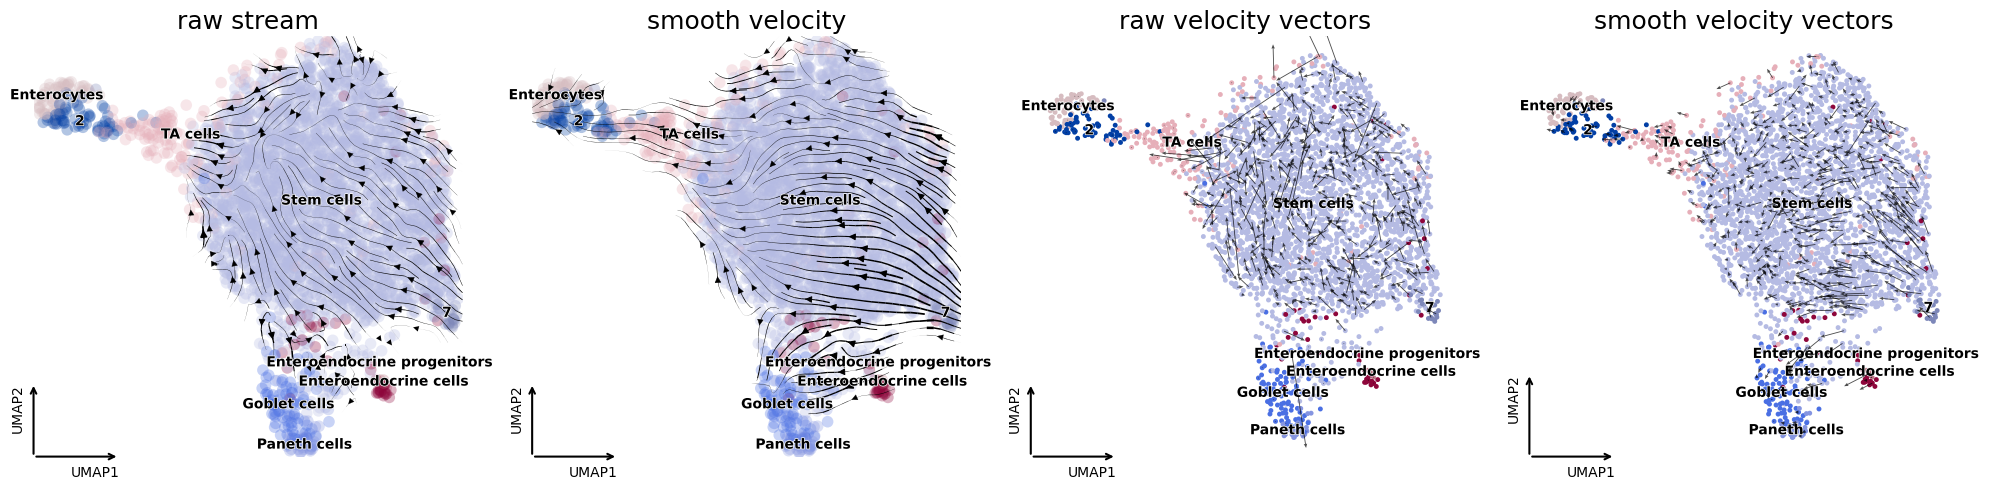

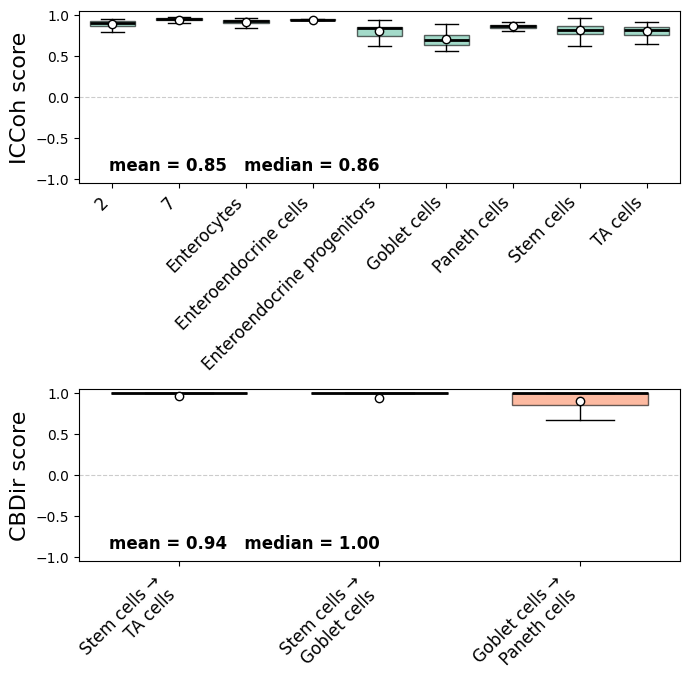

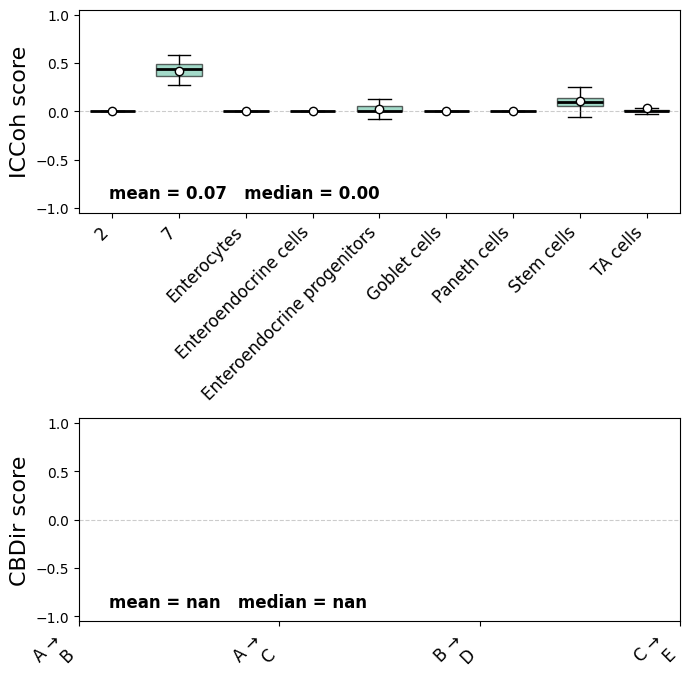

In [32]:

velot.tl.velocity(
    adata,
    **{**SHARED, **METHODS["velot"]},
    basis="X_pca",
    window_size=500,
    n_clusters=1,
    spatial_key=None,
    random_state=0,
)

### Velocity field stream
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
velot.pl.velocity_stream(adata, color="cell_type",
    title="raw stream",
    figsize=(5,5), show=False, ax=axes[0], velocity_key="velot_velocity_raw"
)
velot.pl.velocity_stream(adata, color="cell_type",
    title="smooth velocity",
    figsize=(5,5), show=False, ax=axes[1], velocity_key="velot_velocity"
)
velot.pl.velocity_quiver(adata,
    color="cell_type", basis="umap", subsample=500,
    velocity_key=f"velot_velocity_raw_umap",
    title="raw velocity vectors",
    show=False, ax=axes[2]
)
velot.pl.velocity_quiver(adata,
    color="cell_type", basis="umap", subsample=500,
    velocity_key=f"velot_velocity_umap",
    title="smooth velocity vectors",
    show=False, ax=axes[3]
)
plt.tight_layout()
plt.show()

## CBDir & ICCoh metrics
edges=[
    ("Stem cells", "TA cells"),
    ("Stem cells", "Goblet cells"),
    ("Goblet cells", "Paneth cells")
]
results = velot.metrics.summary(adata,
    cluster_edges=edges, cluster_key="cell_type",
    embedding_key=f"X_pca", velocity_key=f"velot_velocity_pca",
    print_results=False
)
velot.pl.metric_summary(results,
    orientation="vertical", layout="column",
    figsize=(7,7), show=True
)
edges = [("A", "B"), ("A", "C"), ("B", "D"), ("C", "E")]
results = velot.metrics.summary(adata,
    cluster_edges=edges, cluster_key="cell_type",
    embedding_key=f"X_pca", velocity_key=f"velot_velocity_raw_pca",
    print_results=False
)
velot.pl.metric_summary(results,
    orientation="vertical", layout="column",
    figsize=(7,7), show=True
)

In [ ]:
# Real erythroid dataset
## VelOT pipeline & imports
import velot
import scanpy as sc

import matplotlib.pyplot as plt
## Set-up parameters
Quick set-up parameters for cell-type cluster identification and velocity embedding projection as well as visualization configuration.
figures_path = None
show = True
save = False
basis = "pca"
project_umap = True if basis == "pca" else False
clusters_key = "milestone"
## Data loading & preprocessing
# Load data
try:
    adata = sc.read_h5ad("../../article/data/Synthetic/synthetic_linear_processed_5PCA.h5ad")
except:
    print("No downloaded file found, retrieving from scvelo...")
    adata = velot.datasets.erythroid()

# velot.pp.pseudotime(adata, root_cluster="A", cluster_key="milestone")
velot.pp.pseudotime(adata, key="sim_time")
adata.obs["clusters_id"] = adata.obs[clusters_key].cat.codes
We can have a quick overview of the dataset and the pseudotime computed using DPT.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

velot.pl.dataset_overview_simple(adata, color=clusters_key,
    title="Cell-type clusters", inframe=True,
    show=False, ax=axes[0]
)
velot.pl.dataset_overview_simple(adata, color="pseudotime",
    title="Diffusion pseudotime",
    show=False, ax=axes[1]
)
velot.pl.dataset_overview_simple(adata, color="sim_time",
    title="Diffusion pseudotime",
    show=False, ax=axes[2]
)

plt.tight_layout()
plt.show()
## Velocity field computation
Velocity computation can be done using the command `velot.tl.velocity()`. It will internally compute all the `VelOT` steps:
- Build pairs of windows
- Compute OT cost between windows
- Smooth raw OT velocity vectors
- Project the final field to UMAP embedding for visualization
SHARED = dict(
    smooth=True,
    min_window_size=50,
    overlap_fraction=0.0,
    tail_handling="drop",
    tail_threshold=20,
    n_epochs=100,
    lambda_smooth=0.1,
    lambda_curl=0.1,
    lambda_divergence=0.0,
    k_smooth=30,
    project_umap=True,
    verbose=True,
)
METHODS = {
    "velot": dict(use_graph=False, ot_solver="emd")
}
velot.tl.velocity(
    adata,
    **{**SHARED, **METHODS["velot"]},
    basis="X_pca",
    window_size=500,
    n_clusters=1,
    spatial_key=None,
    random_state=0,
)
## Visualization
There are multiple representations available in the pipeline. All of them are accessible via the `velot.pl` module.
### Velocity field stream
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

velot.pl.velocity_stream(adata, color=clusters_key,
    title="VelOT stream velocity",
    figsize=(5,5), show=False, ax=axes[0]
)
velot.pl.dataset_overview_simple(adata, color="velot_confidence",
    title="VelOT velocity confidence",
    show=False, ax=axes[1]
)

plt.tight_layout()
plt.show()
### Raw and smoothed velocity vectors
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

velot.pl.velocity_quiver(adata,
    color=clusters_key, basis="umap", subsample=500,
    velocity_key=f"velot_velocity_raw_umap",
    title="VelOT raw velocity vectors",
    show=False, ax=axes[0]
)
velot.pl.velocity_quiver(adata,
    color=clusters_key, basis="umap", subsample=500,
    velocity_key=f"velot_velocity_umap",
    title="VelOT smooth velocity vectors",
    show=False, ax=axes[1]
)

plt.tight_layout()
plt.show()
## CBDir & ICCoh metrics
edges = [("A", "B"), ("B", "C")]
results = velot.metrics.summary(adata,
    cluster_edges=edges, cluster_key=clusters_key,
    embedding_key=f"X_{basis}", velocity_key=f"velot_velocity_{basis}",
    print_results=False
)
velot.pl.metric_summary(results,
    orientation="vertical", layout="column",
    figsize=(7,7), show=show
)
edges = [("A", "B"), ("B", "C")]
results = velot.metrics.summary(adata,
    cluster_edges=edges, cluster_key=clusters_key,
    embedding_key=f"X_{basis}", velocity_key=f"velot_velocity_raw_{basis}",
    print_results=False
)
velot.pl.metric_summary(results,
    orientation="vertical", layout="column",
    figsize=(7,7), show=show
)
# Real erythroid dataset
## VelOT pipeline & imports
import velot
import scanpy as sc

import matplotlib.pyplot as plt
## Set-up parameters
Quick set-up parameters for cell-type cluster identification and velocity embedding projection as well as visualization configuration.
figures_path = None
show = True
save = False
basis = "pca"
project_umap = True if basis == "pca" else False
clusters_key = "milestone"
## Data loading & preprocessing
# Load data
try:
    adata = sc.read_h5ad("../../article/data/Synthetic/synthetic_trifurcation_processed_5PCA.h5ad")
except:
    print("No downloaded file found, retrieving from scvelo...")
    adata = velot.datasets.erythroid()

velot.pp.pseudotime(adata, root_cluster="A", cluster_key="milestone")
# velot.pp.pseudotime(adata, key="sim_time")
adata.obs["clusters_id"] = adata.obs[clusters_key].cat.codes
We can have a quick overview of the dataset and the pseudotime computed using DPT.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

velot.pl.dataset_overview_simple(adata, color=clusters_key,
    title="Cell-type clusters", inframe=True,
    show=False, ax=axes[0]
)
velot.pl.dataset_overview_simple(adata, color="pseudotime",
    title="Diffusion pseudotime",
    show=False, ax=axes[1]
)
velot.pl.dataset_overview_simple(adata, color="sim_time",
    title="Diffusion pseudotime",
    show=False, ax=axes[2]
)

plt.tight_layout()
plt.show()
## Velocity field computation
Velocity computation can be done using the command `velot.tl.velocity()`. It will internally compute all the `VelOT` steps:
- Build pairs of windows
- Compute OT cost between windows
- Smooth raw OT velocity vectors
- Project the final field to UMAP embedding for visualization
SHARED = dict(
    smooth=True,
    min_window_size=50,
    overlap_fraction=0.0,
    tail_handling="drop",
    tail_threshold=20,
    n_epochs=100,
    lambda_smooth=0.1,
    lambda_curl=0.1,
    lambda_divergence=0.0,
    k_smooth=30,
    project_umap=True,
    verbose=True,
)
METHODS = {
    "velot": dict(use_graph=False, ot_solver="emd")
}
velot.tl.velocity(
    adata,
    **{**SHARED, **METHODS["velot"]},
    basis="X_pca",
    window_size=100,
    n_clusters=1,
    spatial_key=None,
    random_state=0,
)
## Visualization
There are multiple representations available in the pipeline. All of them are accessible via the `velot.pl` module.
### Velocity field stream
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

velot.pl.velocity_stream(adata, color=clusters_key,
    title="VelOT stream velocity",
    figsize=(5,5), show=False, ax=axes[0]
)
velot.pl.dataset_overview_simple(adata, color="velot_confidence",
    title="VelOT velocity confidence",
    show=False, ax=axes[1]
)

plt.tight_layout()
plt.show()
### Raw and smoothed velocity vectors
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

velot.pl.velocity_quiver(adata,
    color=clusters_key, basis="umap", subsample=500,
    velocity_key=f"velot_velocity_raw_umap",
    title="VelOT raw velocity vectors",
    show=False, ax=axes[0]
)
velot.pl.velocity_quiver(adata,
    color=clusters_key, basis="umap", subsample=500,
    velocity_key=f"velot_velocity_umap",
    title="VelOT smooth velocity vectors",
    show=False, ax=axes[1]
)

plt.tight_layout()
plt.show()
## CBDir & ICCoh metrics
edges=[("A", "B"), ("B", "C"), ("C", "F"),
               ("B", "D"), ("D", "G"), ("E", "H")]
results = velot.metrics.summary(adata,
    cluster_edges=edges, cluster_key=clusters_key,
    embedding_key=f"X_{basis}", velocity_key=f"velot_velocity_{basis}",
    print_results=False
)
velot.pl.metric_summary(results,
    orientation="vertical", layout="column",
    figsize=(7,7), show=show
)
edges=[("A", "B"), ("B", "C"), ("C", "F"),
               ("B", "D"), ("D", "G"), ("E", "H")]
results = velot.metrics.summary(adata,
    cluster_edges=edges, cluster_key=clusters_key,
    embedding_key=f"X_{basis}", velocity_key=f"velot_velocity_raw_{basis}",
    print_results=False
)
velot.pl.metric_summary(results,
    orientation="vertical", layout="column",
    figsize=(7,7), show=show
)


# Real erythroid dataset

## VelOT pipeline & imports

In [1]:
import velot
import scanpy as sc

import matplotlib.pyplot as plt

## Set-up parameters

Quick set-up parameters for cell-type cluster identification and velocity embedding projection as well as visualization configuration.

In [2]:
figures_path = None
show = True
save = False
basis = "pca"
project_umap = True if basis == "pca" else False
clusters_key = "milestone"

## Data loading & preprocessing

In [3]:
# Load data
try:
    adata = sc.read_h5ad("../../article/data/Synthetic/synthetic_bifurcation_processed_5PCA.h5ad")
except:
    print("No downloaded file found, retrieving from scvelo...")
    adata = velot.datasets.erythroid()

velot.pp.pseudotime(adata, root_cluster="A", cluster_key="milestone")
adata.obs["clusters_id"] = adata.obs[clusters_key].cat.codes

We can have a quick overview of the dataset and the pseudotime computed using DPT.

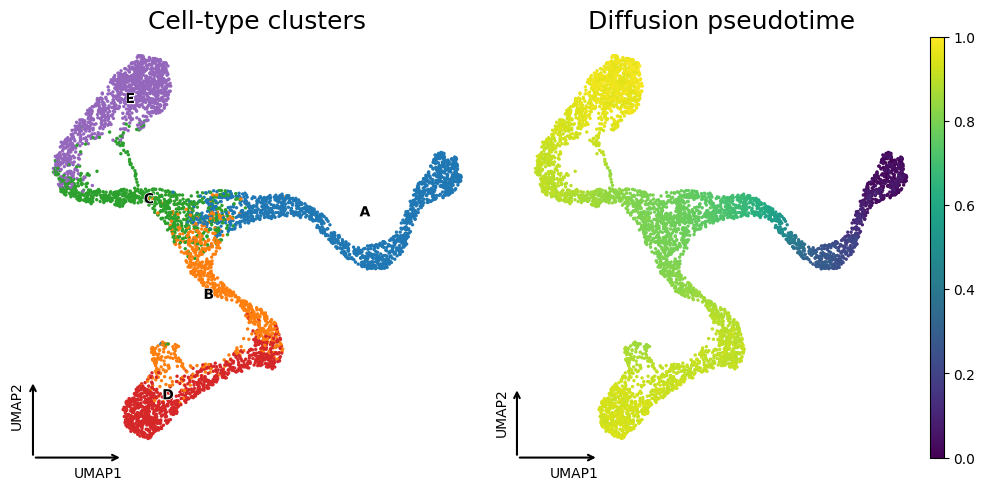

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

velot.pl.dataset_overview_simple(adata, color=clusters_key,
    title="Cell-type clusters", inframe=True,
    show=False, ax=axes[0]
)
velot.pl.dataset_overview_simple(adata, color="pseudotime",
    title="Diffusion pseudotime",
    show=False, ax=axes[1]
)

plt.tight_layout()
plt.show()

## Velocity field computation

Velocity computation can be done using the command `velot.tl.velocity()`. It will internally compute all the `VelOT` steps:
- Build pairs of windows
- Compute OT cost between windows
- Smooth raw OT velocity vectors
- Project the final field to UMAP embedding for visualization

In [5]:
SHARED = dict(
    smooth=True,
    min_window_size=50,
    overlap_fraction=0.0,
    tail_handling="drop",
    tail_threshold=20,
    n_epochs=100,
    lambda_smooth=0.1,
    lambda_curl=0.1,
    lambda_divergence=0.0,
    k_smooth=30,
    project_umap=True,
    verbose=True,
)

In [6]:
METHODS = {
    "velot": dict(use_graph=False, ot_solver="emd")
}

In [7]:
velot.tl.velocity(
    adata,
    **{**SHARED, **METHODS["velot"]},
    basis="X_pca",
    window_size=500,
    n_clusters=1,
    spatial_key=None,
    random_state=0,
)

VelOT: Computing velocity field
  Estimator: ot / emd, euclidean cost/max, barycentric, no kNN graph
  Basis: X_pca (5D)
  Cells: 5000
  Smoothing: ON

[1/4] Building spatial-temporal windows...
  Spatial clustering: 1 clusters via KMeans on X_pca (5D)
  Built 9 window pairs across 1 clusters (skipped 0 small clusters)
  Window size: 500, step: 500

[2/4] Computing OT velocity...
  OT velocity computed: 4500 cells with velocity, 500 without (500 never a source) (will be filled by smoothing)
  Plan sharpness: mean targets per cell (n_eff) = 1
  Typical move per pair (spacing units, the unit of reg_m): median 21.7, max 253

[3/4] Smoothing velocity field...
Found torch compatible version. Running on cuda device
    epoch 50/100: total=1.1771 reg=7.3023 smooth=0.0090 curl=0.0608
    epoch 100/100: total=1.2512 reg=8.4020 smooth=0.0063 curl=0.0410
  Smoothing complete: final total=1.2512

[4/4] Projecting to UMAP...
  Velocity projected to UMAP (5000 cells)
  Velocity projected to UMAP (50

AnnData object with n_obs × n_vars = 5000 × 65
    obs: 'step_ix', 'simulation_i', 'sim_time', 'milestone', 'dpt_pseudotime', 'pseudotime', 'clusters_id', 'velot_spatial_cluster', 'velot_confidence', 'velot_transported_mass'
    var: 'module_id', 'basal', 'burn', 'independence', 'color', 'is_tf', 'is_hk', 'transcription_rate', 'splicing_rate', 'translation_rate', 'mrna_halflife', 'protein_halflife', 'mrna_decay_rate', 'protein_decay_rate', 'max_premrna', 'max_mrna', 'max_protein', 'mol_premrna', 'mol_mrna', 'mol_protein'
    uns: 'log1p', 'milestone_colors', 'neighbors', 'pca', 'traj_dimred_segments', 'traj_milestone_network', 'traj_progressions', 'umap', 'diffmap_evals', 'iroot', 'velot_root', 'velot_windows', 'velot_raw_velocity_params', 'velot_smoothing'
    obsm: 'X_pca', 'X_umap', 'dimred', 'X_diffmap', 'velot_velocity_raw_pca', 'velot_velocity_pca', 'velot_velocity_raw_umap', 'velot_velocity_umap'
    varm: 'PCs'
    layers: 'counts_protein', 'counts_spliced', 'counts_unspliced',

  Spatial clustering: 1 clusters via KMeans on X_pca (5D)
  Built 9 window pairs across 1 clusters (skipped 0 small clusters)
  Window size: 500, step: 500


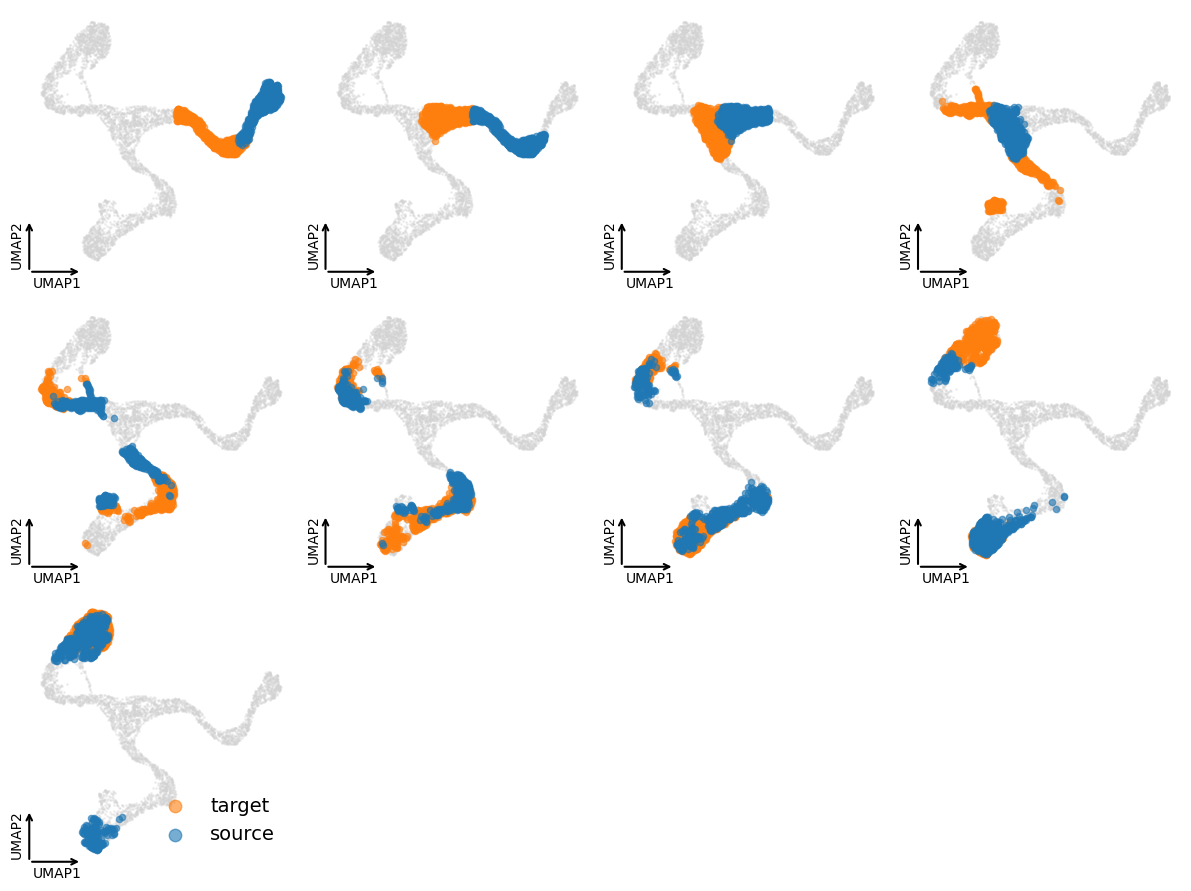

In [13]:
velot.tl.build_windows(adata, "X_pca", 1, 500, 0, 50, None, "drop", 20, 0)
velot.pl.windows(adata)

## Visualization

There are multiple representations available in the pipeline. All of them are accessible via the `velot.pl` module.

### Velocity field stream

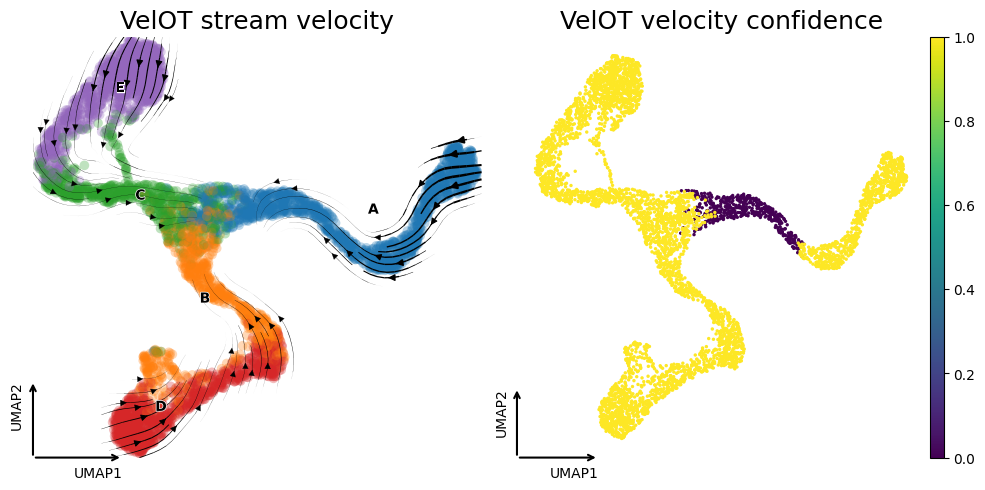

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

velot.pl.velocity_stream(adata, color=clusters_key,
    title="VelOT stream velocity",
    figsize=(5,5), show=False, ax=axes[0]
)
velot.pl.dataset_overview_simple(adata, color="velot_confidence",
    title="VelOT velocity confidence",
    show=False, ax=axes[1]
)

plt.tight_layout()
plt.show()

### Raw and smoothed velocity vectors

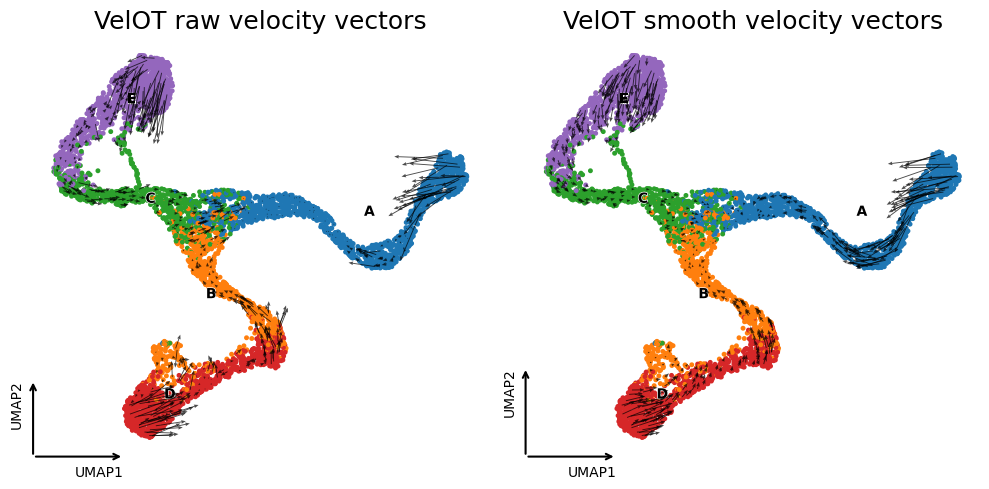

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

velot.pl.velocity_quiver(adata,
    color=clusters_key, basis="umap", subsample=500,
    velocity_key=f"velot_velocity_raw_umap",
    title="VelOT raw velocity vectors",
    show=False, ax=axes[0]
)
velot.pl.velocity_quiver(adata,
    color=clusters_key, basis="umap", subsample=500,
    velocity_key=f"velot_velocity_umap",
    title="VelOT smooth velocity vectors",
    show=False, ax=axes[1]
)

plt.tight_layout()
plt.show()

## CBDir & ICCoh metrics

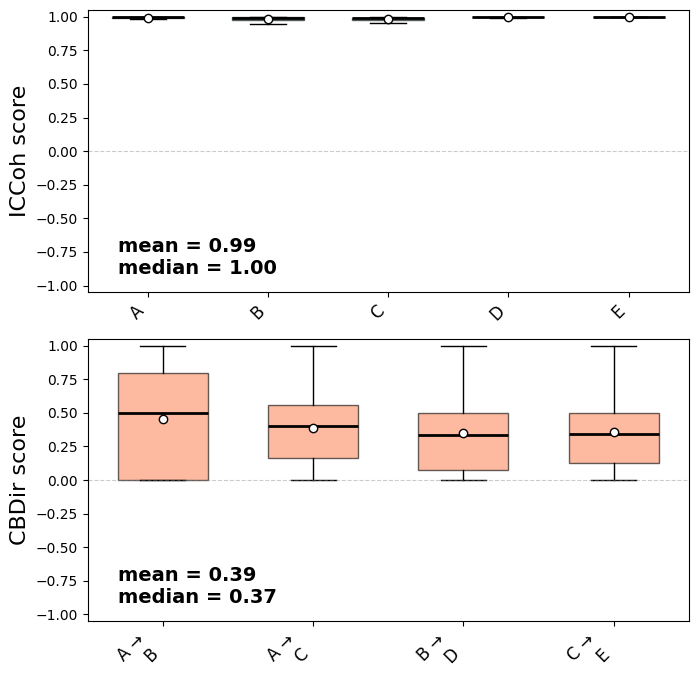

In [24]:
edges = [("A", "B"), ("A", "C"), ("B", "D"), ("C", "E")]
results = velot.metrics.summary(adata,
    cluster_edges=edges, cluster_key=clusters_key,
    embedding_key=f"X_{basis}", velocity_key=f"velot_velocity_{basis}",
    print_results=False
)
velot.pl.metric_summary(results,
    orientation="vertical", layout="column",
    figsize=(7,7), show=show
)

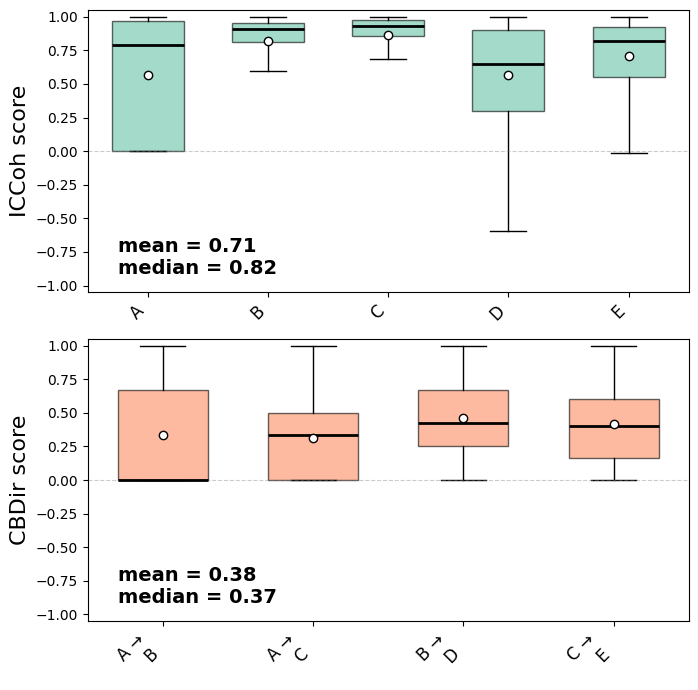

In [25]:
edges = [("A", "B"), ("A", "C"), ("B", "D"), ("C", "E")]
results = velot.metrics.summary(adata,
    cluster_edges=edges, cluster_key=clusters_key,
    embedding_key=f"X_{basis}", velocity_key=f"velot_velocity_raw_{basis}",
    print_results=False
)
velot.pl.metric_summary(results,
    orientation="vertical", layout="column",
    figsize=(7,7), show=show
)

# Real erythroid dataset

## VelOT pipeline & imports

In [ ]:
import velot
import scanpy as sc

import matplotlib.pyplot as plt

## Set-up parameters

Quick set-up parameters for cell-type cluster identification and velocity embedding projection as well as visualization configuration.

In [ ]:
figures_path = None
show = True
save = False
basis = "pca"
project_umap = True if basis == "pca" else False
clusters_key = "milestone"

## Data loading & preprocessing

In [ ]:
# Load data
try:
    adata = sc.read_h5ad("../../article/data/Synthetic/synthetic_linear_processed_5PCA.h5ad")
except:
    print("No downloaded file found, retrieving from scvelo...")
    adata = velot.datasets.erythroid()

# velot.pp.pseudotime(adata, root_cluster="A", cluster_key="milestone")
velot.pp.pseudotime(adata, key="sim_time")
adata.obs["clusters_id"] = adata.obs[clusters_key].cat.codes

We can have a quick overview of the dataset and the pseudotime computed using DPT.

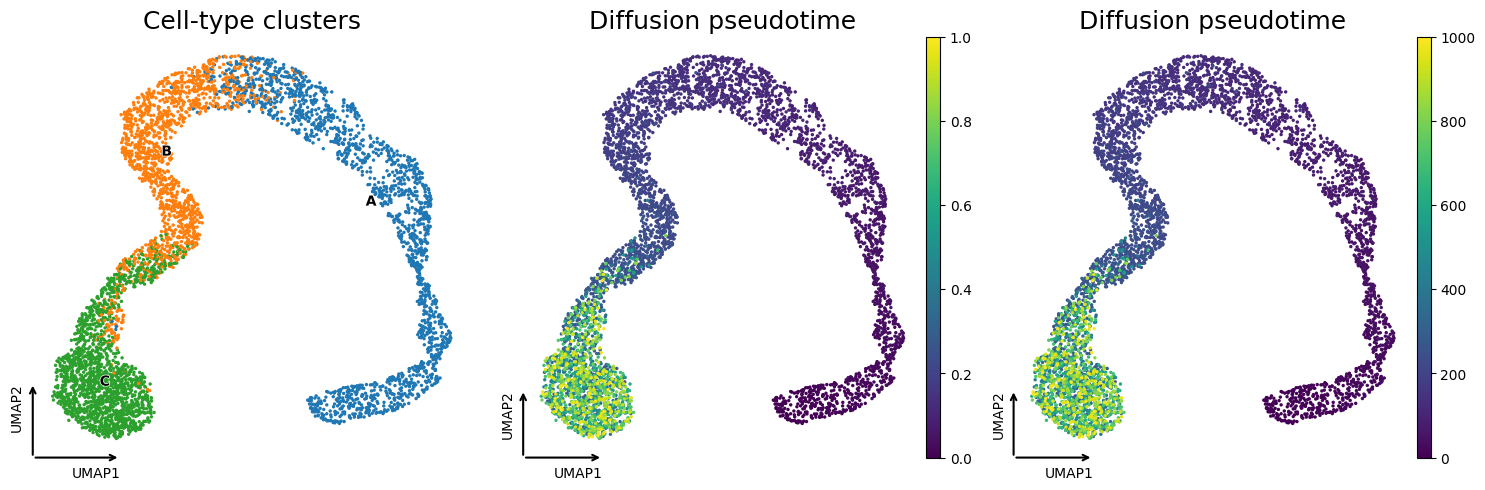

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

velot.pl.dataset_overview_simple(adata, color=clusters_key,
    title="Cell-type clusters", inframe=True,
    show=False, ax=axes[0]
)
velot.pl.dataset_overview_simple(adata, color="pseudotime",
    title="Diffusion pseudotime",
    show=False, ax=axes[1]
)
velot.pl.dataset_overview_simple(adata, color="sim_time",
    title="Diffusion pseudotime",
    show=False, ax=axes[2]
)

plt.tight_layout()
plt.show()

## Velocity field computation

Velocity computation can be done using the command `velot.tl.velocity()`. It will internally compute all the `VelOT` steps:
- Build pairs of windows
- Compute OT cost between windows
- Smooth raw OT velocity vectors
- Project the final field to UMAP embedding for visualization

In [ ]:
SHARED = dict(
    smooth=True,
    min_window_size=50,
    overlap_fraction=0.0,
    tail_handling="drop",
    tail_threshold=20,
    n_epochs=100,
    lambda_smooth=0.1,
    lambda_curl=0.1,
    lambda_divergence=0.0,
    k_smooth=30,
    project_umap=True,
    verbose=True,
)

In [ ]:
METHODS = {
    "velot": dict(use_graph=False, ot_solver="emd")
}

In [ ]:
velot.tl.velocity(
    adata,
    **{**SHARED, **METHODS["velot"]},
    basis="X_pca",
    window_size=500,
    n_clusters=1,
    spatial_key=None,
    random_state=0,
)

VelOT: Computing velocity field
  Estimator: ot / emd, euclidean cost/max, barycentric, no kNN graph
  Basis: X_pca (5D)
  Cells: 5000
  Smoothing: ON

[1/4] Building spatial-temporal windows...
  Spatial clustering: 1 clusters via KMeans on X_pca (5D)
  Built 9 window pairs across 1 clusters (skipped 0 small clusters)
  Window size: 500, step: 500

[2/4] Computing OT velocity...
  OT velocity computed: 4500 cells with velocity, 500 without (500 never a source) (will be filled by smoothing)
  Plan sharpness: mean targets per cell (n_eff) = 1
  Typical move per pair (spacing units, the unit of reg_m): median 2.86, max 23.5

[3/4] Smoothing velocity field...
Found torch compatible version. Running on cuda device
    epoch 50/100: total=0.8175 reg=1.3447 smooth=0.0076 curl=0.1893
    epoch 100/100: total=0.8279 reg=1.3642 smooth=0.0083 curl=0.1706
  Smoothing complete: final total=0.8279

[4/4] Projecting to UMAP...
  Velocity projected to UMAP (5000 cells)
  Velocity projected to UMAP (5

AnnData object with n_obs × n_vars = 5000 × 51
    obs: 'step_ix', 'simulation_i', 'sim_time', 'milestone', 'pseudotime', 'clusters_id', 'velot_spatial_cluster', 'velot_confidence', 'velot_transported_mass'
    var: 'module_id', 'basal', 'burn', 'independence', 'color', 'is_tf', 'is_hk', 'transcription_rate', 'splicing_rate', 'translation_rate', 'mrna_halflife', 'protein_halflife', 'mrna_decay_rate', 'protein_decay_rate', 'max_premrna', 'max_mrna', 'max_protein', 'mol_premrna', 'mol_mrna', 'mol_protein'
    uns: 'log1p', 'milestone_colors', 'neighbors', 'pca', 'traj_dimred_segments', 'traj_milestone_network', 'traj_progressions', 'umap', 'velot_windows', 'velot_raw_velocity_params', 'velot_smoothing'
    obsm: 'X_pca', 'X_umap', 'dimred', 'velot_velocity_raw_pca', 'velot_velocity_pca', 'velot_velocity_raw_umap', 'velot_velocity_umap'
    varm: 'PCs'
    layers: 'counts_protein', 'counts_spliced', 'counts_unspliced', 'logcounts', 'rna_velocity'
    obsp: 'connectivities', 'distances'

## Visualization

There are multiple representations available in the pipeline. All of them are accessible via the `velot.pl` module.

### Velocity field stream

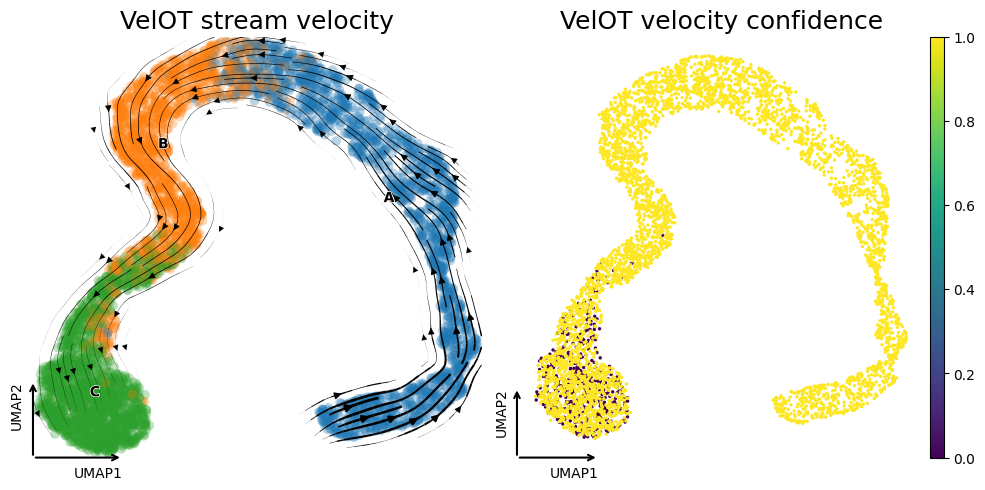

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

velot.pl.velocity_stream(adata, color=clusters_key,
    title="VelOT stream velocity",
    figsize=(5,5), show=False, ax=axes[0]
)
velot.pl.dataset_overview_simple(adata, color="velot_confidence",
    title="VelOT velocity confidence",
    show=False, ax=axes[1]
)

plt.tight_layout()
plt.show()

### Raw and smoothed velocity vectors

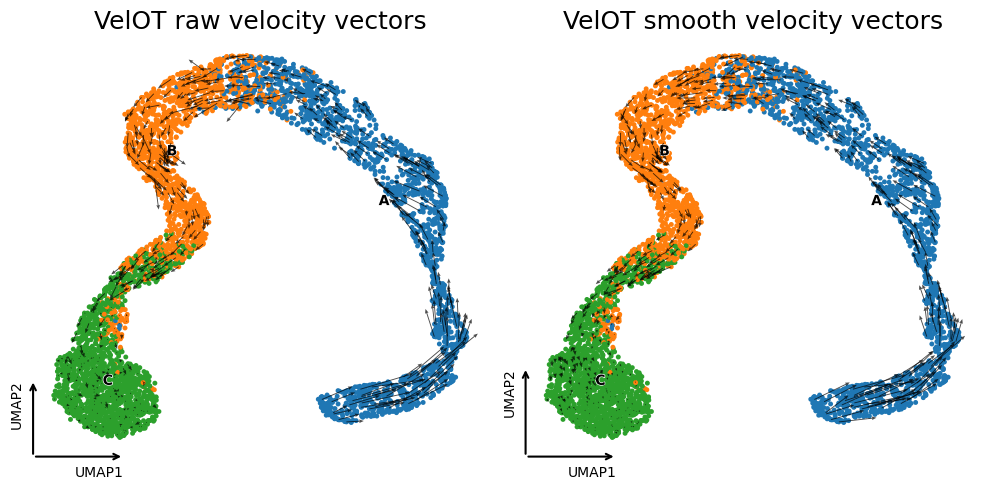

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

velot.pl.velocity_quiver(adata,
    color=clusters_key, basis="umap", subsample=500,
    velocity_key=f"velot_velocity_raw_umap",
    title="VelOT raw velocity vectors",
    show=False, ax=axes[0]
)
velot.pl.velocity_quiver(adata,
    color=clusters_key, basis="umap", subsample=500,
    velocity_key=f"velot_velocity_umap",
    title="VelOT smooth velocity vectors",
    show=False, ax=axes[1]
)

plt.tight_layout()
plt.show()

## CBDir & ICCoh metrics

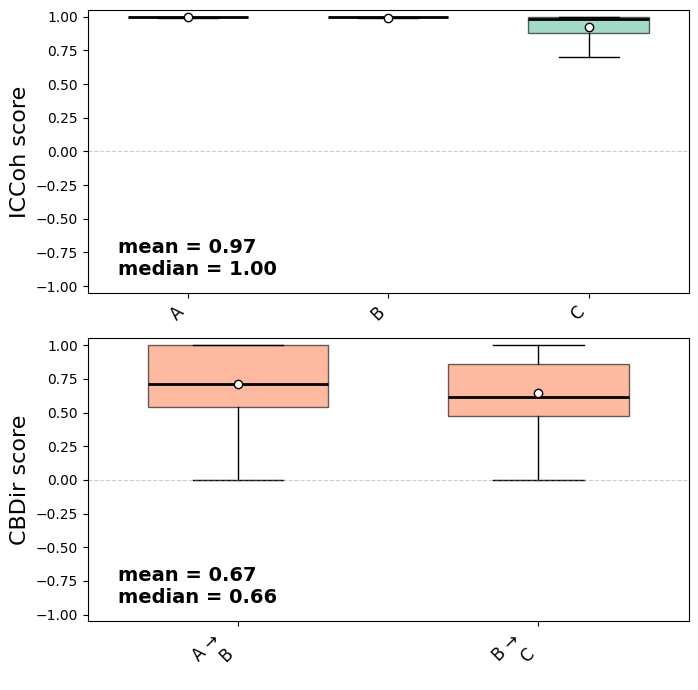

In [ ]:
edges = [("A", "B"), ("B", "C")]
results = velot.metrics.summary(adata,
    cluster_edges=edges, cluster_key=clusters_key,
    embedding_key=f"X_{basis}", velocity_key=f"velot_velocity_{basis}",
    print_results=False
)
velot.pl.metric_summary(results,
    orientation="vertical", layout="column",
    figsize=(7,7), show=show
)

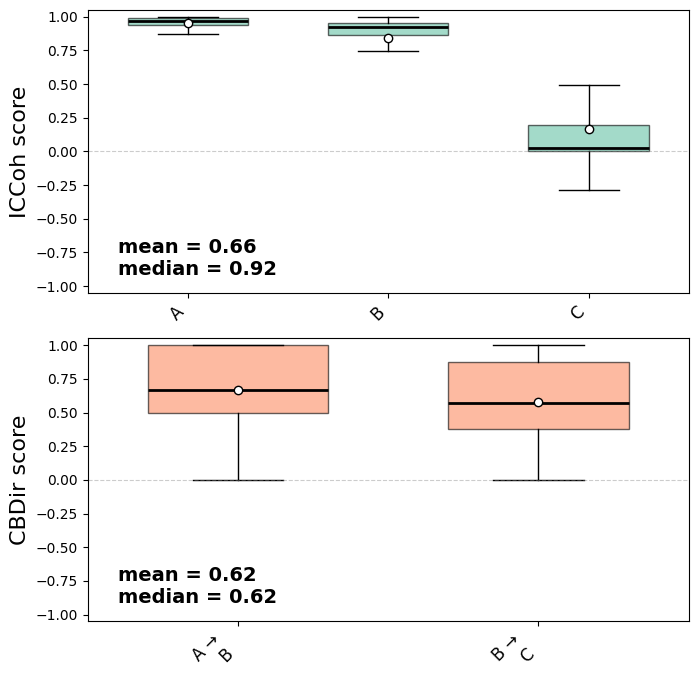

In [ ]:
edges = [("A", "B"), ("B", "C")]
results = velot.metrics.summary(adata,
    cluster_edges=edges, cluster_key=clusters_key,
    embedding_key=f"X_{basis}", velocity_key=f"velot_velocity_raw_{basis}",
    print_results=False
)
velot.pl.metric_summary(results,
    orientation="vertical", layout="column",
    figsize=(7,7), show=show
)

# Real erythroid dataset

## VelOT pipeline & imports

In [17]:
import velot
import scanpy as sc

import matplotlib.pyplot as plt

## Set-up parameters

Quick set-up parameters for cell-type cluster identification and velocity embedding projection as well as visualization configuration.

In [18]:
figures_path = None
show = True
save = False
basis = "pca"
project_umap = True if basis == "pca" else False
clusters_key = "milestone"

## Data loading & preprocessing

In [30]:
# Load data
try:
    adata = sc.read_h5ad("../../article/data/Synthetic/synthetic_trifurcation_processed_5PCA.h5ad")
except:
    print("No downloaded file found, retrieving from scvelo...")
    adata = velot.datasets.erythroid()

velot.pp.pseudotime(adata, root_cluster="A", cluster_key="milestone")
# velot.pp.pseudotime(adata, key="sim_time")
adata.obs["clusters_id"] = adata.obs[clusters_key].cat.codes

We can have a quick overview of the dataset and the pseudotime computed using DPT.

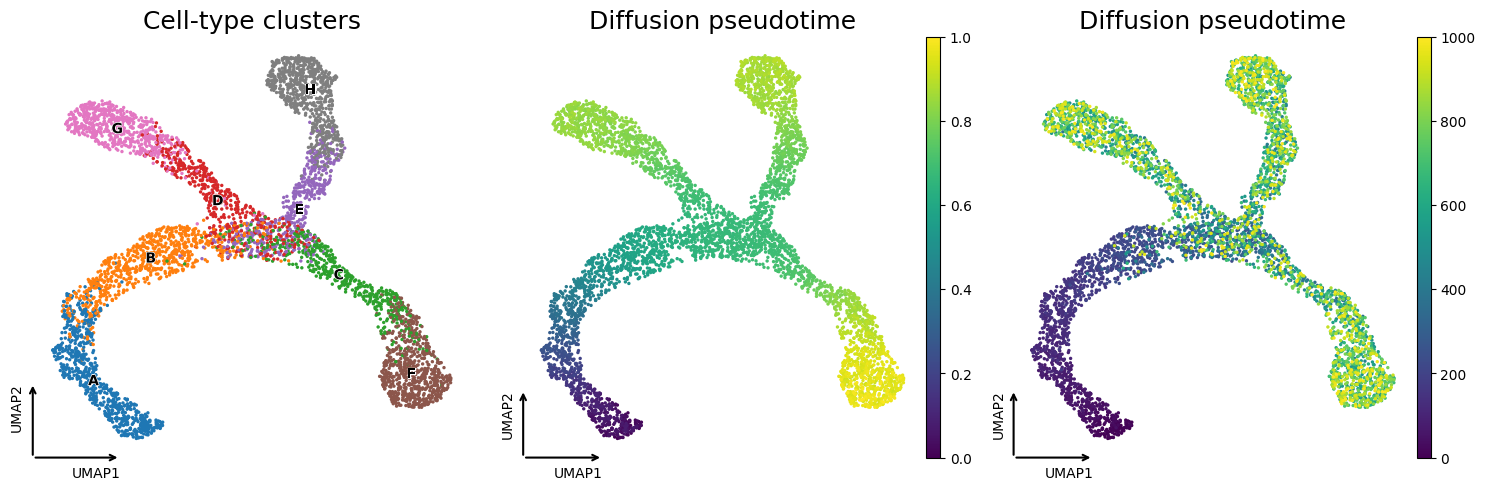

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

velot.pl.dataset_overview_simple(adata, color=clusters_key,
    title="Cell-type clusters", inframe=True,
    show=False, ax=axes[0]
)
velot.pl.dataset_overview_simple(adata, color="pseudotime",
    title="Diffusion pseudotime",
    show=False, ax=axes[1]
)
velot.pl.dataset_overview_simple(adata, color="sim_time",
    title="Diffusion pseudotime",
    show=False, ax=axes[2]
)

plt.tight_layout()
plt.show()

## Velocity field computation

Velocity computation can be done using the command `velot.tl.velocity()`. It will internally compute all the `VelOT` steps:
- Build pairs of windows
- Compute OT cost between windows
- Smooth raw OT velocity vectors
- Project the final field to UMAP embedding for visualization

In [32]:
SHARED = dict(
    smooth=True,
    min_window_size=50,
    overlap_fraction=0.0,
    tail_handling="drop",
    tail_threshold=20,
    n_epochs=100,
    lambda_smooth=0.1,
    lambda_curl=0.1,
    lambda_divergence=0.0,
    k_smooth=30,
    project_umap=True,
    verbose=True,
)

In [33]:
METHODS = {
    "velot": dict(use_graph=False, ot_solver="emd")
}

In [34]:
velot.tl.velocity(
    adata,
    **{**SHARED, **METHODS["velot"]},
    basis="X_pca",
    window_size=100,
    n_clusters=1,
    spatial_key=None,
    random_state=0,
)

VelOT: Computing velocity field
  Estimator: ot / emd, euclidean cost/max, barycentric, no kNN graph
  Basis: X_pca (5D)
  Cells: 5000
  Smoothing: ON

[1/4] Building spatial-temporal windows...
  Spatial clustering: 1 clusters via KMeans on X_pca (5D)
  Built 49 window pairs across 1 clusters (skipped 0 small clusters)
  Window size: 100, step: 100

[2/4] Computing OT velocity...
  OT velocity computed: 4900 cells with velocity, 100 without (100 never a source) (will be filled by smoothing)
  Plan sharpness: mean targets per cell (n_eff) = 1
  Typical move per pair (spacing units, the unit of reg_m): median 1.81, max 5.19

[3/4] Smoothing velocity field...
Found torch compatible version. Running on cuda device
    epoch 50/100: total=0.8679 reg=2.2610 smooth=0.0002 curl=0.0001
    epoch 100/100: total=1.4117 reg=3.7152 smooth=0.0002 curl=0.0001
  Smoothing complete: final total=1.4117

[4/4] Projecting to UMAP...
  Velocity projected to UMAP (5000 cells)
  Velocity projected to UMAP (

AnnData object with n_obs × n_vars = 5000 × 82
    obs: 'step_ix', 'simulation_i', 'sim_time', 'milestone', 'dpt_pseudotime', 'pseudotime', 'clusters_id', 'velot_spatial_cluster', 'velot_confidence', 'velot_transported_mass'
    var: 'module_id', 'basal', 'burn', 'independence', 'color', 'is_tf', 'is_hk', 'transcription_rate', 'splicing_rate', 'translation_rate', 'mrna_halflife', 'protein_halflife', 'mrna_decay_rate', 'protein_decay_rate', 'max_premrna', 'max_mrna', 'max_protein', 'mol_premrna', 'mol_mrna', 'mol_protein'
    uns: 'log1p', 'milestone_colors', 'neighbors', 'pca', 'traj_dimred_segments', 'traj_milestone_network', 'traj_progressions', 'umap', 'diffmap_evals', 'iroot', 'velot_root', 'velot_windows', 'velot_raw_velocity_params', 'velot_smoothing'
    obsm: 'X_pca', 'X_umap', 'dimred', 'X_diffmap', 'velot_velocity_raw_pca', 'velot_velocity_pca', 'velot_velocity_raw_umap', 'velot_velocity_umap'
    varm: 'PCs'
    layers: 'counts_protein', 'counts_spliced', 'counts_unspliced',

## Visualization

There are multiple representations available in the pipeline. All of them are accessible via the `velot.pl` module.

### Velocity field stream

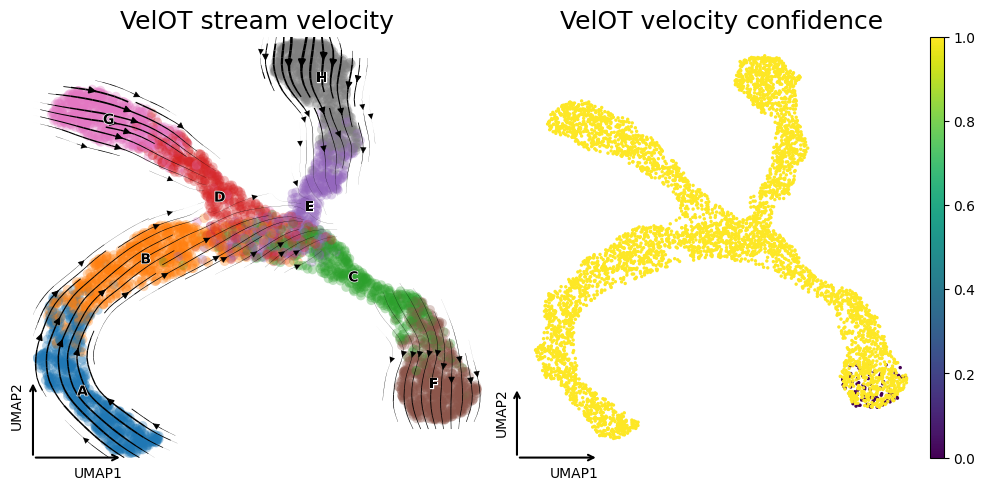

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

velot.pl.velocity_stream(adata, color=clusters_key,
    title="VelOT stream velocity",
    figsize=(5,5), show=False, ax=axes[0]
)
velot.pl.dataset_overview_simple(adata, color="velot_confidence",
    title="VelOT velocity confidence",
    show=False, ax=axes[1]
)

plt.tight_layout()
plt.show()

### Raw and smoothed velocity vectors

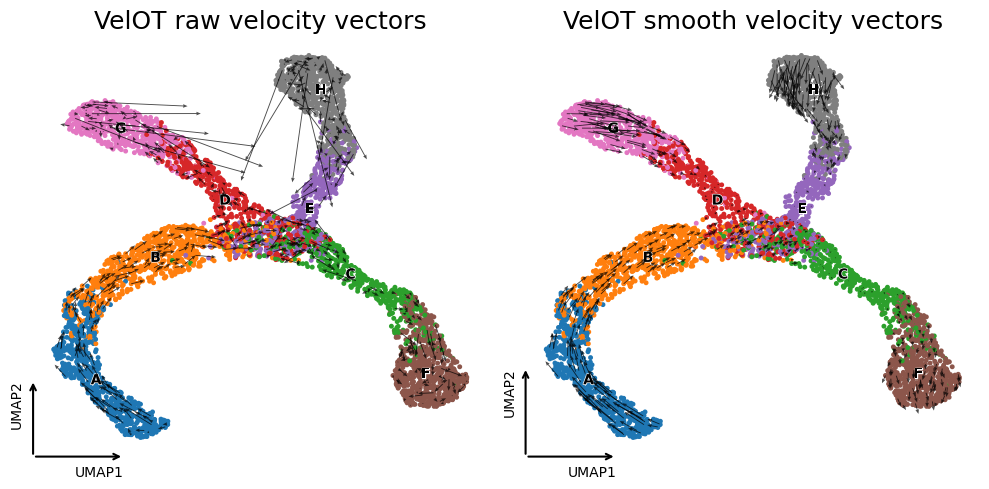

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

velot.pl.velocity_quiver(adata,
    color=clusters_key, basis="umap", subsample=500,
    velocity_key=f"velot_velocity_raw_umap",
    title="VelOT raw velocity vectors",
    show=False, ax=axes[0]
)
velot.pl.velocity_quiver(adata,
    color=clusters_key, basis="umap", subsample=500,
    velocity_key=f"velot_velocity_umap",
    title="VelOT smooth velocity vectors",
    show=False, ax=axes[1]
)

plt.tight_layout()
plt.show()

## CBDir & ICCoh metrics

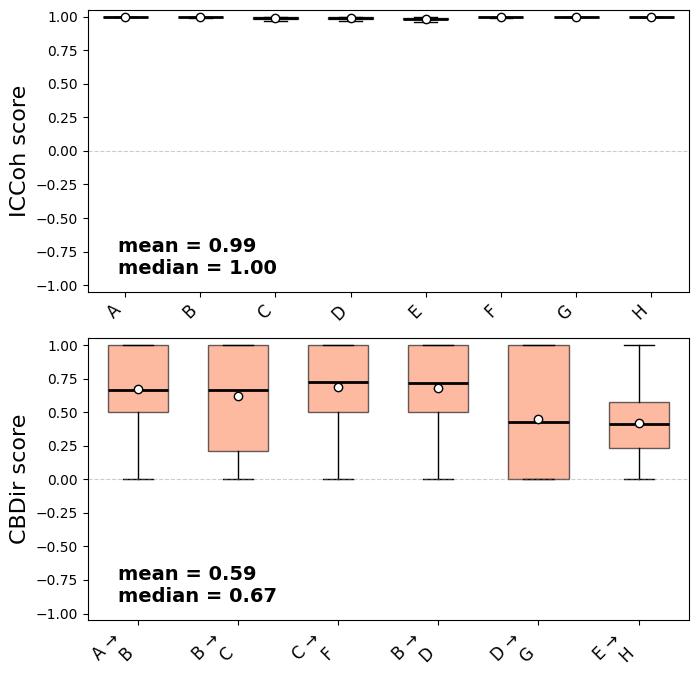

In [37]:
edges=[("A", "B"), ("B", "C"), ("C", "F"),
               ("B", "D"), ("D", "G"), ("E", "H")]
results = velot.metrics.summary(adata,
    cluster_edges=edges, cluster_key=clusters_key,
    embedding_key=f"X_{basis}", velocity_key=f"velot_velocity_{basis}",
    print_results=False
)
velot.pl.metric_summary(results,
    orientation="vertical", layout="column",
    figsize=(7,7), show=show
)

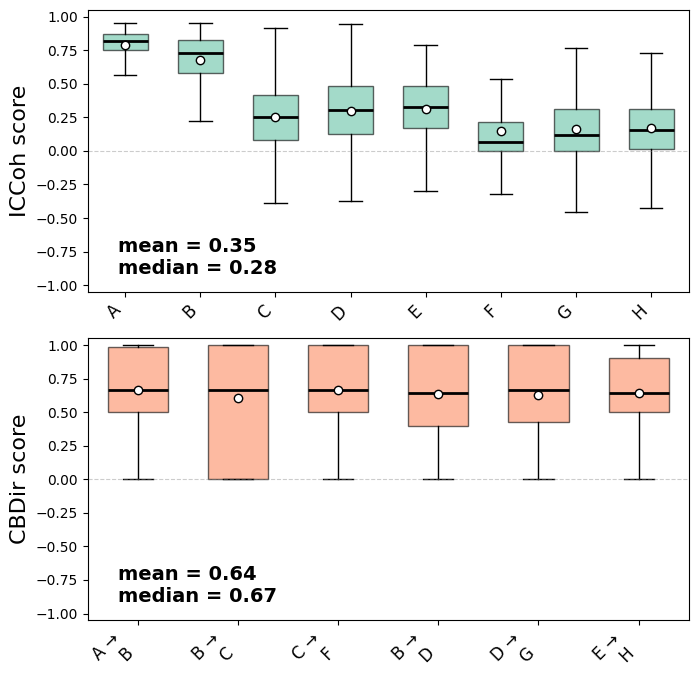

In [38]:
edges=[("A", "B"), ("B", "C"), ("C", "F"),
               ("B", "D"), ("D", "G"), ("E", "H")]
results = velot.metrics.summary(adata,
    cluster_edges=edges, cluster_key=clusters_key,
    embedding_key=f"X_{basis}", velocity_key=f"velot_velocity_raw_{basis}",
    print_results=False
)
velot.pl.metric_summary(results,
    orientation="vertical", layout="column",
    figsize=(7,7), show=show
)